In [62]:
from experiments.silver_seq import silver_seq_utils as utils
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load data and filter out low expression genes.
In this method, genes must be above the threshold in at least one sample.


In [ ]:
X, silver_seq_counts, silver_seq_meta = utils.load_silver_seq_data()
print(f'genes before filtering = {X.shape}')
# filter low max expression
min_threshold = 45
X = X.loc[X.max(axis=1) >= min_threshold]
print(f'genes after filter {min_threshold} = {X.shape}')

# Normalize
import numpy as np

# CPM normalization
library_sizes = X.sum(axis=1)

X_cpm = X.div(library_sizes, axis=0) * 1e6

#log transform
X_log = np.log2(X_cpm + 1)

print(X_log.shape)
# print(X.head(3))

genes before filtering = (60675, 115)
genes after filter 45 = (10700, 115)
(10700, 115)


In [4]:
#annotate if sample is last (at death)
silver_seq_meta['is_last_sample'] = silver_seq_meta.groupby('donor_id_alias')['year_sample'].transform('max') == silver_seq_meta['year_sample']

#apoe4 status encoded differently
def apoe_num(val):
  val=str(val)
  if val=='44':
    return 2
  if '4' in val:
    return 1
  return 0

silver_seq_meta['apoe2'] = [apoe_num(v) for v in silver_seq_meta['apoe']]

# Metadata Features

In [ ]:
import pandas as pd
#prep metadata featurs
#convert 'sex' and 'apoe' into numeric columns
features = ['age_at_collection', 'sex', 'apoe2']
X_meta = pd.get_dummies(silver_seq_meta[features], drop_first=True)
#set index of X_meta to match the sample IDs
X_meta.index = silver_seq_meta['sample_id_alias']
y_meta = silver_seq_meta['donor_group']
#align
y_meta.index = silver_seq_meta['sample_id_alias']
print(X_meta.head(3))

                 age_at_collection  apoe2  sex_M
sample_id_alias                                 
AD_1_02_1                       74      1  False
AD_1_04_1                       76      1  False
AD_1_08_1                       80      1  False


# Stacking Features

In [ ]:
def stack_meta(X_t, X_meta): #uncomment for debugging, all fixed now!
  # print("stack meta")
  # print("------X_t--------------")
  # print(X_t.head(3))
  meta_features = X_meta.reindex(X_t.index)
  # print("------meta--------------")
  # print(meta_features.head(3))
  X_all = pd.concat([X_t, meta_features], axis=1)
  # print("------all--------------")
  # print(X_all.head(3))
  return X_all

X_t = X.head(3).T
X_all = stack_meta(X_t, X_meta)

# Standard Classifier/Feature Test

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_val_score

In [ ]:
from sklearn.metrics import roc_auc_score, accuracy_score

#for LODO (Leave One Donor Out) Cross validation
def donor_strat_cross_val(clf, X, y, scoring="roc_auc"):
    #dictionary containing {donor: [donor1_sample1, donor1_sample3], ...}
    samples_per_donor = {}
    for sample in X.index:
        donor = '_'.join(sample.split('_')[:2])
        if donor not in samples_per_donor:
            samples_per_donor[donor] = []
        samples_per_donor[donor].append(sample)

    #needed vars for accumulation across ''folds'
    all_y_true = []
    all_y_pred_proba = []
    all_y_pred_label = []

    # iterate over the donors by leaving one out at a time
    for excluded_donor, excluded_samples in samples_per_donor.items():
        #split
        train_samples = [sample for donor, samples in samples_per_donor.items() if donor != excluded_donor for sample in samples]

        X_train = X.loc[train_samples]
        y_train = y.loc[train_samples]
        X_test = X.loc[excluded_samples]
        y_test = y.loc[excluded_samples]

        #train
        clf.fit(X_train, y_train)

        #true labels
        all_y_true.extend(y_test.values)

        #collect preds
        if scoring == 'roc_auc':
            #probabilities for the positive class (column 1)
            probabilities = clf.predict_proba(X_test)[:, 1]
            all_y_pred_proba.extend(probabilities)
        elif scoring == 'accuracy':
            labels = clf.predict(X_test)
            all_y_pred_label.extend(labels)
        else:
            raise ValueError("Specified scoring metric not yet implemented for donor stratified split.")

    #global eval once two classes have been collected
    if scoring == 'roc_auc':
        # Now we have a mix of classes in all_y_true, allowing global AUC calculation
        return roc_auc_score(all_y_true, all_y_pred_proba)

    elif scoring == 'accuracy':
        return accuracy_score(all_y_true, all_y_pred_label)

In [9]:
def run_classifier(X, y, clf, cv, name="Test", description="test description",
                   model_name='not specified', feats_description='not specified', scores={}):
  # print(name)
  # print(X.head(3))
  scores[name] = {'score': cross_val_score(clf, X, y, cv=cv, scoring="roc_auc"),
                  'lodo_roc_auc': donor_strat_cross_val(clf, X, y, scoring="roc_auc"),
                  "description": description,
                  "model": model_name,
                  "features": feats_description,
                  "n_features": X.shape[1],
                  "n_samples": X.shape[0]}
  return scores

def run_with_and_without_meta(X, y, clf, cv, X_meta, base_name="Test",
                              description="test description",
                              model_name='not specified', feats_description='not specified',
                              scores={}):
  X_all = stack_meta(X, X_meta)
  scores_all = run_classifier(X_all, y, clf, cv,
                                name=base_name + "_plus_meta",
                                description=description + "plus metadata",
                                model_name=model_name, feats_description=feats_description + ' + meta',
                                scores=scores)
  score_x = run_classifier(X, y, clf, cv,
                           name=base_name,
                           description=description,
                           model_name=model_name, feats_description=feats_description,
                           scores=scores)


rfc = RandomForestClassifier(n_estimators=100, random_state=42)
lrc = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=5000,
                                  random_state=42,
                                  class_weight="balanced"))
    ])

cv_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_gkf = GroupKFold(n_splits=5)

scores = {}

# Baseline Classifiers

### Metadata-only

In [10]:
run_classifier(X_meta, y_meta, lrc, cv_skf,
               name="meta_lrc_cv_skf",
               description="Metadata only, logistic regression, StratifiedKFold",
               model_name='logistic regression', feats_description='metadata',
               scores=scores)

run_classifier(X_meta, y_meta, rfc, cv_skf,
               name="meta_rfc_cv_skf",
               description="Metadata only, random forest, StratifiedKFold",
               model_name='random forest', feats_description='metadata',
               scores=scores)

{'meta_lrc_cv_skf': {'score': array([0.625     , 0.69583333, 0.68333333, 0.49166667, 0.89285714]),
  'lodo_roc_auc': np.float64(0.5329597890573501),
  'description': 'Metadata only, logistic regression, StratifiedKFold',
  'model': 'logistic regression',
  'features': 'metadata',
  'n_features': 3,
  'n_samples': 115},
 'meta_rfc_cv_skf': {'score': array([0.70833333, 0.8375    , 0.82083333, 0.53333333, 0.81349206]),
  'lodo_roc_auc': np.float64(0.5451549110085695),
  'description': 'Metadata only, random forest, StratifiedKFold',
  'model': 'random forest',
  'features': 'metadata',
  'n_features': 3,
  'n_samples': 115}}

# Filter Genes Based on Gene Sets
- Gene Ontology (GO) terms
- Pathways from public pathway databases
- Generated by network clustering of DEGs

Gene sets are computed separately. Loaded here from CSV files.

In [12]:
gene_sets = pd.read_csv(EXP_DIR + "/" + 'gene_sets.csv')

def classify_by_gene_sets(X, X_meta, gene_sets, scores={}):
  for i in range(gene_sets.shape[0]):
    set = gene_sets.iloc[i]
    # Handle gene_list being a string or NaN (for description if needed, not strictly for current error)
    gene_list_raw = set.get("gene_list")
    if isinstance(gene_list_raw, str):
        gene_list = gene_list_raw.split(" ")
    else:
        gene_list = [] # Treat as empty list if not a string

    id_list_raw = set.get("id_list")
    if isinstance(id_list_raw, str):
        id_list = id_list_raw.split(" ")
    else:
        id_list = [] # Treat as empty list if not a string

    gene_set_name = set["name"]

    # Filter genes from X
    filtered_genes = X.loc[X.index.isin(id_list), :]

    # Check if filtered_genes is empty
    if filtered_genes.empty:
        print(f"Warning: Gene set '{gene_set_name}' has no genes present in the input data X. Skipping classification for this set.")
        continue

    X_gs = filtered_genes.T # Transpose to have samples as rows, genes as columns
    #y = [1 if s.split("_")[0] == "AD" else 0 for s in X_gs.index] #LH TEST OG (commented)
    # Convert y to a pandas Series with the correct index #LH TEST
    y = pd.Series([1 if s.split("_")[0] == "AD" else 0 for s in X_gs.index], index=X_gs.index) #LH tes
    # print(X_gs.head(3))

    run_with_and_without_meta(X_gs, y,
                              lrc, cv_skf,
                              X_meta,
                              base_name=gene_set_name + "_lrc_cv_skf",
                              description=gene_set_name,
                              model_name='logistic regression', feats_description=gene_set_name,
                              scores=scores)
    run_with_and_without_meta(X_gs, y,
                              rfc, cv_skf,
                              X_meta,
                              base_name=gene_set_name + "_rfc_cv_skf",
                              description=gene_set_name,
                              model_name='random forest', feats_description=gene_set_name,
                              scores=scores)

classify_by_gene_sets(X_log, X_meta, gene_sets, scores=scores)



In [13]:
for run, info in scores.items():
  print(f"{info['score'].mean():.3f} lodo = {info['lodo_roc_auc']:.3f} n_f={info['n_features']} - {info['features']} - {run}: ")

0.678 lodo = 0.533 n_f=3 - metadata - meta_lrc_cv_skf: 
0.743 lodo = 0.545 n_f=3 - metadata - meta_rfc_cv_skf: 
0.601 lodo = 0.477 n_f=77 - AD network + meta - AD network_lrc_cv_skf_plus_meta: 
0.552 lodo = 0.444 n_f=74 - AD network - AD network_lrc_cv_skf: 
0.510 lodo = 0.236 n_f=77 - AD network + meta - AD network_rfc_cv_skf_plus_meta: 
0.429 lodo = 0.233 n_f=74 - AD network - AD network_rfc_cv_skf: 
0.533 lodo = 0.440 n_f=17 - neurodegen-autophagy + meta - neurodegen-autophagy_lrc_cv_skf_plus_meta: 
0.356 lodo = 0.360 n_f=14 - neurodegen-autophagy - neurodegen-autophagy_lrc_cv_skf: 
0.575 lodo = 0.379 n_f=17 - neurodegen-autophagy + meta - neurodegen-autophagy_rfc_cv_skf_plus_meta: 
0.475 lodo = 0.346 n_f=14 - neurodegen-autophagy - neurodegen-autophagy_rfc_cv_skf: 
0.595 lodo = 0.482 n_f=9 - oxidative demethylation + meta - oxidative demethylation_lrc_cv_skf_plus_meta: 
0.424 lodo = 0.409 n_f=6 - oxidative demethylation - oxidative demethylation_lrc_cv_skf: 
0.603 lodo = 0.386 n_f=

# Filter Genes Based on Features That Aggregate Expression Across a Gene Set

Features are created by aggregating expression values over a gene set.

Potential aggregation functions: max, mean, median

AD network
neurodegen-autophagy
oxidative demethylation
oxidative phosphorylation
oxidative RNA demethylation
AKT/MTOR pathway I
release of cytochrome c from mitochondria
autophagic cell death
MT Genes
PHGDH interactors
PHGDH
S13 AD-associated lncRNAs
AD-only functional lncRNAs
Downregulated core lncRNAs in AD
AD-only functional protein-coding genes
Previously reported AD hub genes
V-ATPase key genes
Therapeutic target candidates
Harold 2009 AD GWAS loci
Corneveaux 2010 top AD genes
Second-wave AD GWAS genes
Strongest AD GWAS loci after APOE
AD microglial innate immunity genes

In [14]:
aggregation_feature_sets = {
    # "group:AD network": ["AD network"],
    # "group:neurodegen-autophagy": ["neurodegen-autophagy"],
    # "group:oxidative demethylation": ["oxidative demethylation"],
    "group:oxidative phosphorylation": ["oxidative phosphorylation"],
    # "group:oxidative RNA demethylation": ["oxidative RNA demethylation"],
    # "group:AKT/MTOR pathway I": ["AKT/MTOR pathway I"],
    "group:release of cytochrome c from mitochondria": ["release of cytochrome c from mitochondria"],
    # "group:autophagic cell death": ["autophagic cell death"],
    "group:MT genes": ["MT Genes"],
    # "group:PHGDH interactors": ["PHGDH interactors"],
    # "group:PHGDH": ["PHGDH"],
    # "group:S13 AD-associated lncRNAs": ["S13 AD-associated lncRNAs"],
    # "group:AD-only functional lncRNAs": ["AD-only functional lncRNAs"],
    # "group:Downregulated core lncRNAs in AD": ["Downregulated core lncRNAs in AD"],
    # "group:AD-only functional protein-coding genes": ["AD-only functional protein-coding genes"],
    # "group:Previously reported AD hub genes": ["Previously reported AD hub genes"],
    "group:V-ATPase key genes": ["V-ATPase key genes"],
    # "group:Therapeutic target candidates": ["Therapeutic target candidates"],
    # "group:Harold 2009 AD GWAS loci": ["Harold 2009 AD GWAS loci"],
    # "group:Corneveaux 2010 top AD genes": ["Corneveaux 2010 top AD genes"],
    # "group:Second-wave AD GWAS genes": ["Second-wave AD GWAS genes"],
    # "group:Strongest AD GWAS loci after APOE": ["Strongest AD GWAS loci after APOE"],
    # "group:AD microglial innate immunity genes": ["AD microglial innate immunity genes"]
    "group:top": ["oxidative phosphorylation", "release of cytochrome c from mitochondria", "MT Genes", "V-ATPase key genes"],
    "group:top + PHGDH": ["oxidative phosphorylation", "release of cytochrome c from mitochondria", "MT Genes", "V-ATPase key genes", "PHGDH"]
}


def classify_by_aggregate_features(X, agg_set, gene_sets, agg_set_name="Test",
                                   aggregation_function="mean", scores={}):
  feature_rows = []
  feature_names = []
  # Define y based on the samples (columns of X)
  #y_samples = [1 if s.split("_")[0] == "AD" else 0 for s in X.columns] # LH chnage OG LINE (commented)
  y_list = [1 if s.split("_")[0] == "AD" else 0 for s in X.columns] #LH change
  # Convert y to a pandas Series with the correct index #LH change
  y_samples = pd.Series(y_list, index=X.columns) #LH change

  # make a feature for each gene set name in agg_sets
  for gene_set_name in agg_set:
    gene_set = gene_sets[gene_sets["name"] == gene_set_name]
    # Ensure gene_set is not empty if a gene_set_name isn't found
    if gene_set.empty:
        print(f"Warning: Gene set '{gene_set_name}' not found. Skipping.")
        continue

    gene_list_raw = gene_set["gene_list"].iloc[0]
    # Handle gene_list being a string or NaN
    if isinstance(gene_list_raw, str):
        gene_list = gene_list_raw.split(" ")
    else:
        gene_list = [] # Treat as empty list if not a string

    id_list_raw = gene_set["id_list"].iloc[0]
    # Handle id_list being a string or NaN
    if isinstance(id_list_raw, str):
        id_list = id_list_raw.split(" ")
    else:
        id_list = [] # Treat as empty list if not a string

    # get the subset of gene data
    filtered_genes = X.loc[X.index.isin(id_list)]

    # If filtered_genes is empty, skip this gene set to avoid errors in aggregation
    if filtered_genes.empty:
        print(f"Warning: No genes found for gene set '{gene_set_name}' in the input data X. Skipping.")
        continue

    # aggregate values across samples into a row for the feature df
    if aggregation_function == "max":
      feature_row = filtered_genes.max(axis=0, numeric_only=True).to_frame().T
    else:
      feature_row = filtered_genes.mean(axis=0, numeric_only=True).to_frame().T
    feature_rows.append(feature_row)
    feature_names.append(gene_set_name)

  if not feature_rows:
      print(f"No features generated for agg_set: {agg_set_name}. Skipping classification.")
      return

  # Concatenate along axis=0 to stack rows, making each feature a row
  agg_features = pd.concat(feature_rows, axis=0)
  # Transpose agg_features to have samples as rows and features as columns
  agg_features = agg_features.T
  agg_features.columns = feature_names # Assign column names after transpose

  # classify based on the agg_features
  run_with_and_without_meta(agg_features, y_samples, lrc, cv_skf,
                            X_meta, base_name=agg_set_name + "_lrc",
                            description="features for " + agg_set_name,
                            model_name='logistic regression', feats_description=agg_set_name,
                            scores=scores)
  run_with_and_without_meta(agg_features, y_samples, rfc, cv_skf,
                          X_meta, base_name=agg_set_name+ "_rfc",
                          description="features for " + agg_set_name,
                          model_name='random forest', feats_description=agg_set_name,
                          scores=scores)



# Process all the aggregate feature sets
for name, agg_set in aggregation_feature_sets.items():
  classify_by_aggregate_features(X_log, agg_set, gene_sets,
                                 agg_set_name=name,
                                 aggregation_function="mean",
                                 scores=scores)


In [15]:
for run, info in scores.items():
  print(f"{info['score'].mean():.3f} lodo = {info['lodo_roc_auc']:.3f} n_f={info['n_features']} - {info['features']} - {info['model']} \t\t{run} ")

0.678 lodo = 0.533 n_f=3 - metadata - logistic regression 		meta_lrc_cv_skf 
0.743 lodo = 0.545 n_f=3 - metadata - random forest 		meta_rfc_cv_skf 
0.601 lodo = 0.477 n_f=77 - AD network + meta - logistic regression 		AD network_lrc_cv_skf_plus_meta 
0.552 lodo = 0.444 n_f=74 - AD network - logistic regression 		AD network_lrc_cv_skf 
0.510 lodo = 0.236 n_f=77 - AD network + meta - random forest 		AD network_rfc_cv_skf_plus_meta 
0.429 lodo = 0.233 n_f=74 - AD network - random forest 		AD network_rfc_cv_skf 
0.533 lodo = 0.440 n_f=17 - neurodegen-autophagy + meta - logistic regression 		neurodegen-autophagy_lrc_cv_skf_plus_meta 
0.356 lodo = 0.360 n_f=14 - neurodegen-autophagy - logistic regression 		neurodegen-autophagy_lrc_cv_skf 
0.575 lodo = 0.379 n_f=17 - neurodegen-autophagy + meta - random forest 		neurodegen-autophagy_rfc_cv_skf_plus_meta 
0.475 lodo = 0.346 n_f=14 - neurodegen-autophagy - random forest 		neurodegen-autophagy_rfc_cv_skf 
0.595 lodo = 0.482 n_f=9 - oxidative dem

# Logistic Regression Summary Plot

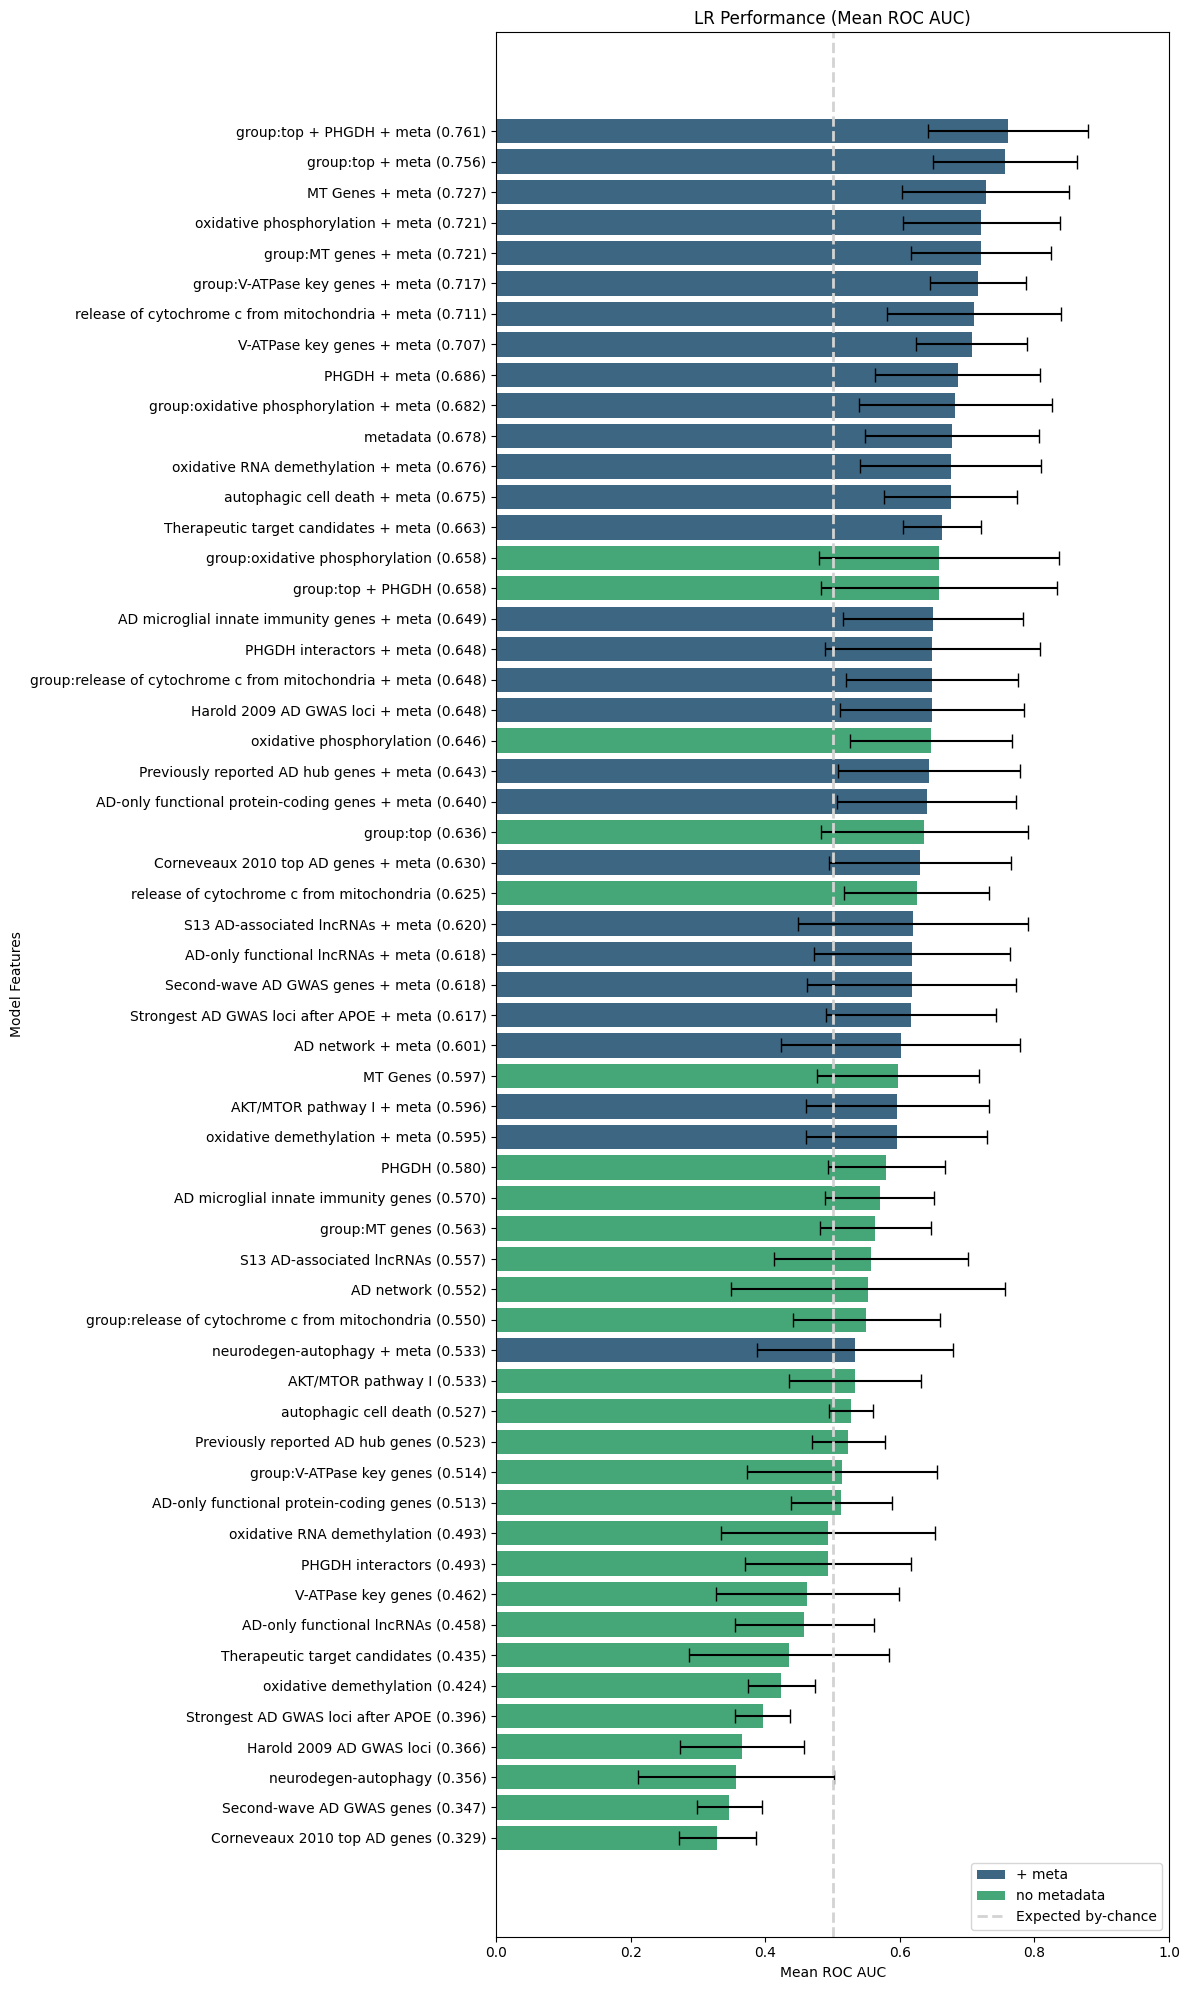

In [ ]:
#prep data
model_names = []
mean_roc_auc = []
std_roc_auc = []
model_type = []
feats=[]
has_meta=[]

for name, data in scores.items():
  if data['model']=='logistic regression':
    model_names.append(name)
    feats.append(data['features'] + f' ({data['score'].mean():.3f})')
    mean_roc_auc.append(data['score'].mean())
    std_roc_auc.append(data['score'].std())
    model_type.append(data['model'])
    has_meta.append("+ meta" if "meta" in data['features'] else "no metadata")

plot_df = pd.DataFrame({
    'Model': model_names,
    'features': feats,
    'Mean ROC AUC': mean_roc_auc,
    'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type,
    "Has metadata": has_meta
})

#sort
plot_df = plot_df.sort_values(by='Mean ROC AUC', ascending=False)

#plot
plt.figure(figsize=(12,20))
sns.barplot(x='Mean ROC AUC', y='features', data=plot_df, hue='Has metadata', dodge=False, palette='viridis')

#add error bars
plt.errorbar(x=plot_df['Mean ROC AUC'], y=plot_df['features'],
             xerr=plot_df['Std Dev ROC AUC'], fmt='none', capsize=5, color='black')

#by chance
plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('LR Performance (Mean ROC AUC)')
plt.xlabel('Mean ROC AUC')
plt.ylabel('Model Features')
plt.xlim(0, 1) 
plt.legend(loc='lower right') 
plt.tight_layout()
plt.show()

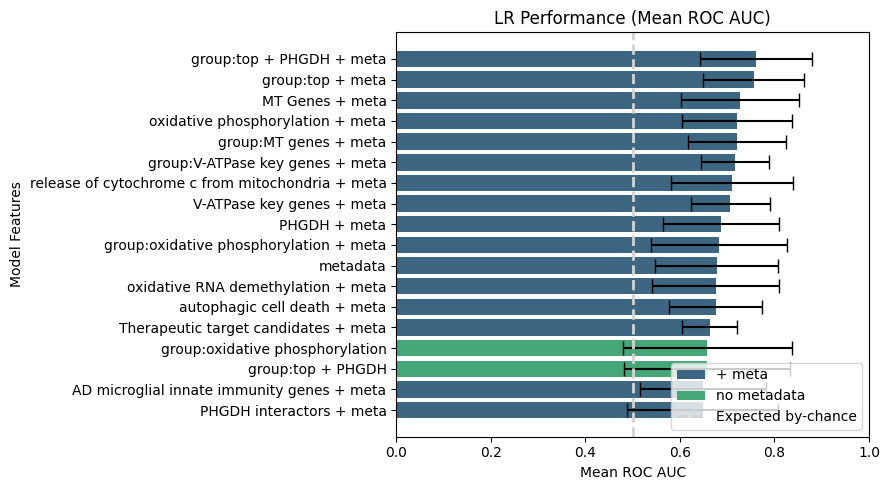

In [ ]:
#prep data
model_names = []
mean_roc_auc = []
std_roc_auc = []
model_type = []
feats=[]
has_meta=[]

for name, data in scores.items():
  if data['model']=='logistic regression':
    model_names.append(name)
    #feats.append(data['features'] + f' ({data['score'].mean():.3f})')
    feats.append(data['features']) #.replace(' + meta', ''))
    mean_roc_auc.append(data['score'].mean())
    std_roc_auc.append(data['score'].std())
    model_type.append(data['model'])
    has_meta.append("+ meta" if "meta" in data['features'] else "no metadata")

plot_df = pd.DataFrame({
    'Model': model_names,
    'features': feats,
    'Mean ROC AUC': mean_roc_auc,
    'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type,
    "Has metadata": has_meta
})

#sort
plot_df = plot_df.sort_values(by='Mean ROC AUC', ascending=False)

#keep only top n
plot_df = plot_df.head(18)

# Create the plot
plt.figure(figsize=(9,5))
sns.barplot(x='Mean ROC AUC', y='features', data=plot_df, hue='Has metadata', dodge=False, palette='viridis')

# Add error bars
plt.errorbar(x=plot_df['Mean ROC AUC'], y=plot_df['features'],
             xerr=plot_df['Std Dev ROC AUC'], fmt='none', capsize=5, color='black')

#by chance
plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('LR Performance (Mean ROC AUC)')
plt.xlabel('Mean ROC AUC')
plt.ylabel('Model Features')
plt.xlim(0, 1) 
plt.legend(loc='lower right') 
plt.tight_layout()
plt.show()

In [18]:
scores['AD microglial innate immunity genes_lrc_cv_skf'].keys()

dict_keys(['score', 'lodo_roc_auc', 'description', 'model', 'features', 'n_features', 'n_samples'])

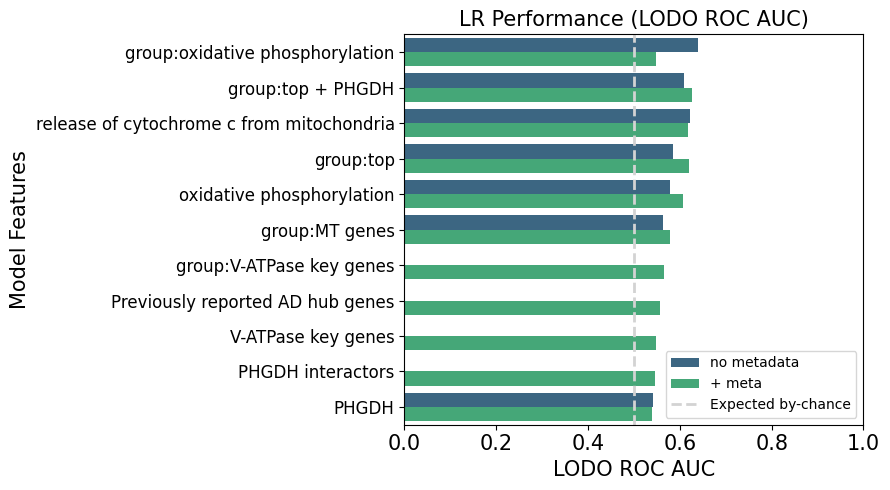

In [ ]:
#prep data
model_names = []
mean_roc_auc = []
std_roc_auc = []
model_type = []
feats=[]
has_meta=[]

for name, data in scores.items():
  if data['model']=='logistic regression':
    model_names.append(name)
    #feats.append(data['features'] + f' ({data['lodo_roc_auc'].mean():.3f})')
    feats.append(data['features'].replace(' + meta', ''))
    mean_roc_auc.append(data['lodo_roc_auc'].mean())
    std_roc_auc.append(data['score'].std())
    model_type.append(data['model'])
    has_meta.append("+ meta" if "meta" in data['features'] else "no metadata")

plot_df = pd.DataFrame({
    'Model': model_names,
    'features': feats,
    'Mean ROC AUC': mean_roc_auc,
    'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type,
    "Has metadata": has_meta
})

#sort
plot_df = plot_df.sort_values(by='Mean ROC AUC', ascending=False)

#keep only top 11
plot_df = plot_df.head(18)

# Create the plot
plt.figure(figsize=(9,5))
sns.barplot(x='Mean ROC AUC', y='features', data=plot_df, hue='Has metadata', dodge=True, palette='viridis')

# Add a vertical dotted line at x=0.5 for 'by-chance' AUC
plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('LR Performance (LODO ROC AUC)', fontsize=15)
plt.xlabel('LODO ROC AUC', fontsize=15)
plt.ylabel('Model Features', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.xlim(0, 1) 
plt.legend(loc='lower right') 
plt.tight_layout()
plt.show()

# Random Forest Summary Plot



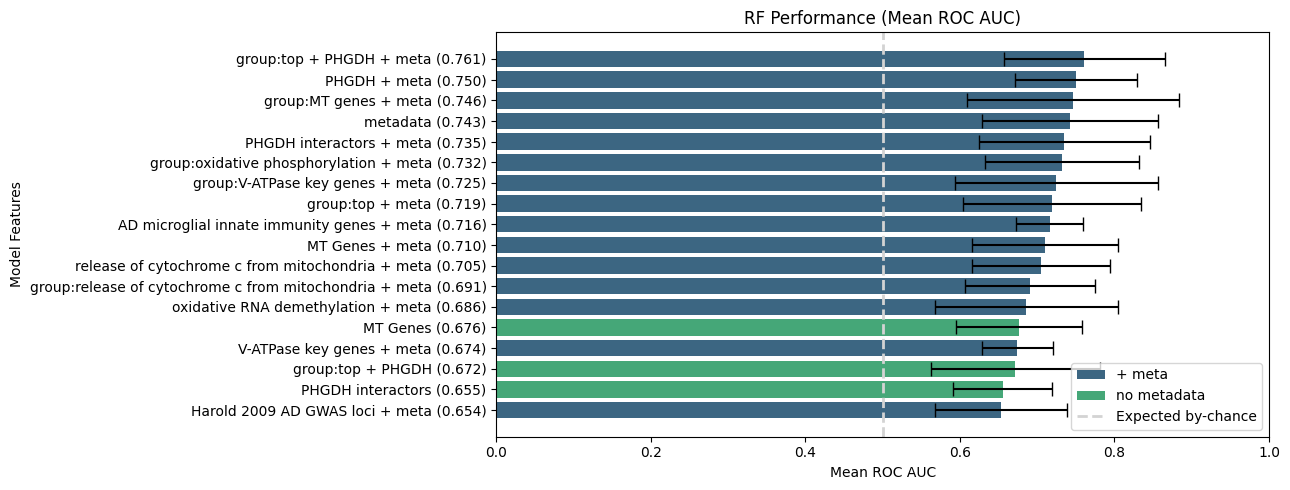

In [ ]:
#proep data
model_names = []
mean_roc_auc = []
std_roc_auc = []
model_type = []
feats=[]
has_meta=[]

for name, data in scores.items():
  if data['model']=='random forest':
    model_names.append(name)
    #feats.append(data['features'] + f' ({data['lodo_roc_auc'].mean():.3f})')
    feats.append(data['features'].replace(' + meta', ''))
    mean_roc_auc.append(data['lodo_roc_auc'].mean())
    std_roc_auc.append(data['score'].std())
    model_type.append(data['model'])
    has_meta.append("+ meta" if "meta" in data['features'] else "no metadata")

plot_df = pd.DataFrame({
    'Model': model_names,
    'features': feats,
    'Mean ROC AUC': mean_roc_auc,
    'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type,
    "Has metadata": has_meta
})

#sort
plot_df = plot_df.sort_values(by='Mean ROC AUC', ascending=False)

#keep only top 11
plot_df = plot_df.head(18)

#plot
plt.figure(figsize=(9,5))
sns.barplot(x='Mean ROC AUC', y='features', data=plot_df, hue='Has metadata', dodge=True, palette='viridis')

#error bars
#plt.errorbar(x=plot_df['Mean ROC AUC'], y=plot_df['features'],
#             xerr=plot_df['Std Dev ROC AUC'], fmt='none', capsize=5, color='black')

#by chance
plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('RF Performance (LODO ROC AUC)', fontsize=15)
plt.xlabel('LODO ROC AUC', fontsize=15)
plt.ylabel('Model Features', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.xlim(0, 1) 
plt.legend(loc='lower right') 
plt.tight_layout()
plt.show()

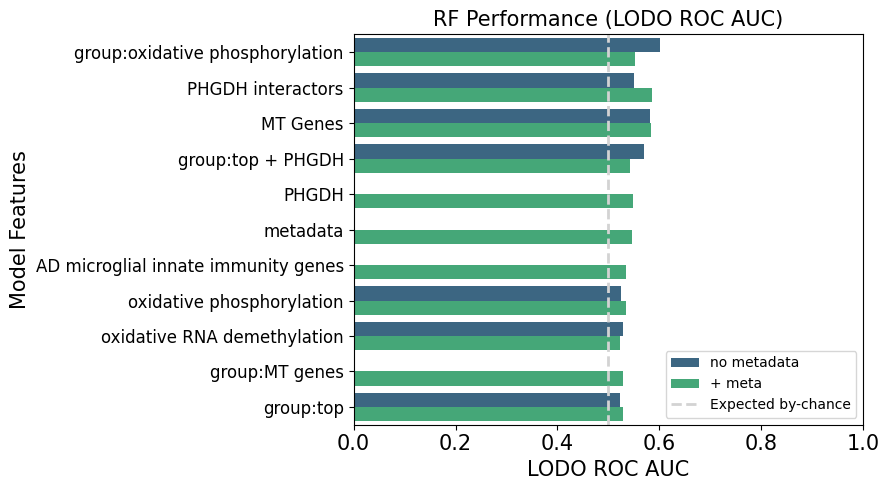

In [ ]:
#prep data
model_names = []
mean_roc_auc = []
std_roc_auc = []
model_type = []
feats=[]
has_meta=[]

for name, data in scores.items():
  if data['model']=='random forest':
    model_names.append(name)
    #feats.append(data['features'] + f' ({data['lodo_roc_auc'].mean():.3f})')
    feats.append(data['features'].replace(' + meta', ''))
    mean_roc_auc.append(data['lodo_roc_auc'].mean())
    std_roc_auc.append(data['score'].std())
    model_type.append(data['model'])
    has_meta.append("+ meta" if "meta" in data['features'] else "no metadata")

plot_df = pd.DataFrame({
    'Model': model_names,
    'features': feats,
    'Mean ROC AUC': mean_roc_auc,
    'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type,
    "Has metadata": has_meta
})

#sort
plot_df = plot_df.sort_values(by='Mean ROC AUC', ascending=False)

#keep only top 11
plot_df = plot_df.head(18)

#plot
plt.figure(figsize=(9,5))
sns.barplot(x='Mean ROC AUC', y='features', data=plot_df, hue='Has metadata', dodge=True, palette='viridis')

plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('RF Performance (LODO ROC AUC)', fontsize=15)
plt.xlabel('LODO ROC AUC', fontsize=15)
plt.ylabel('Model Features', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=12)
plt.xlim(0, 1) 
plt.legend(loc='lower right') 
plt.tight_layout()
plt.show()

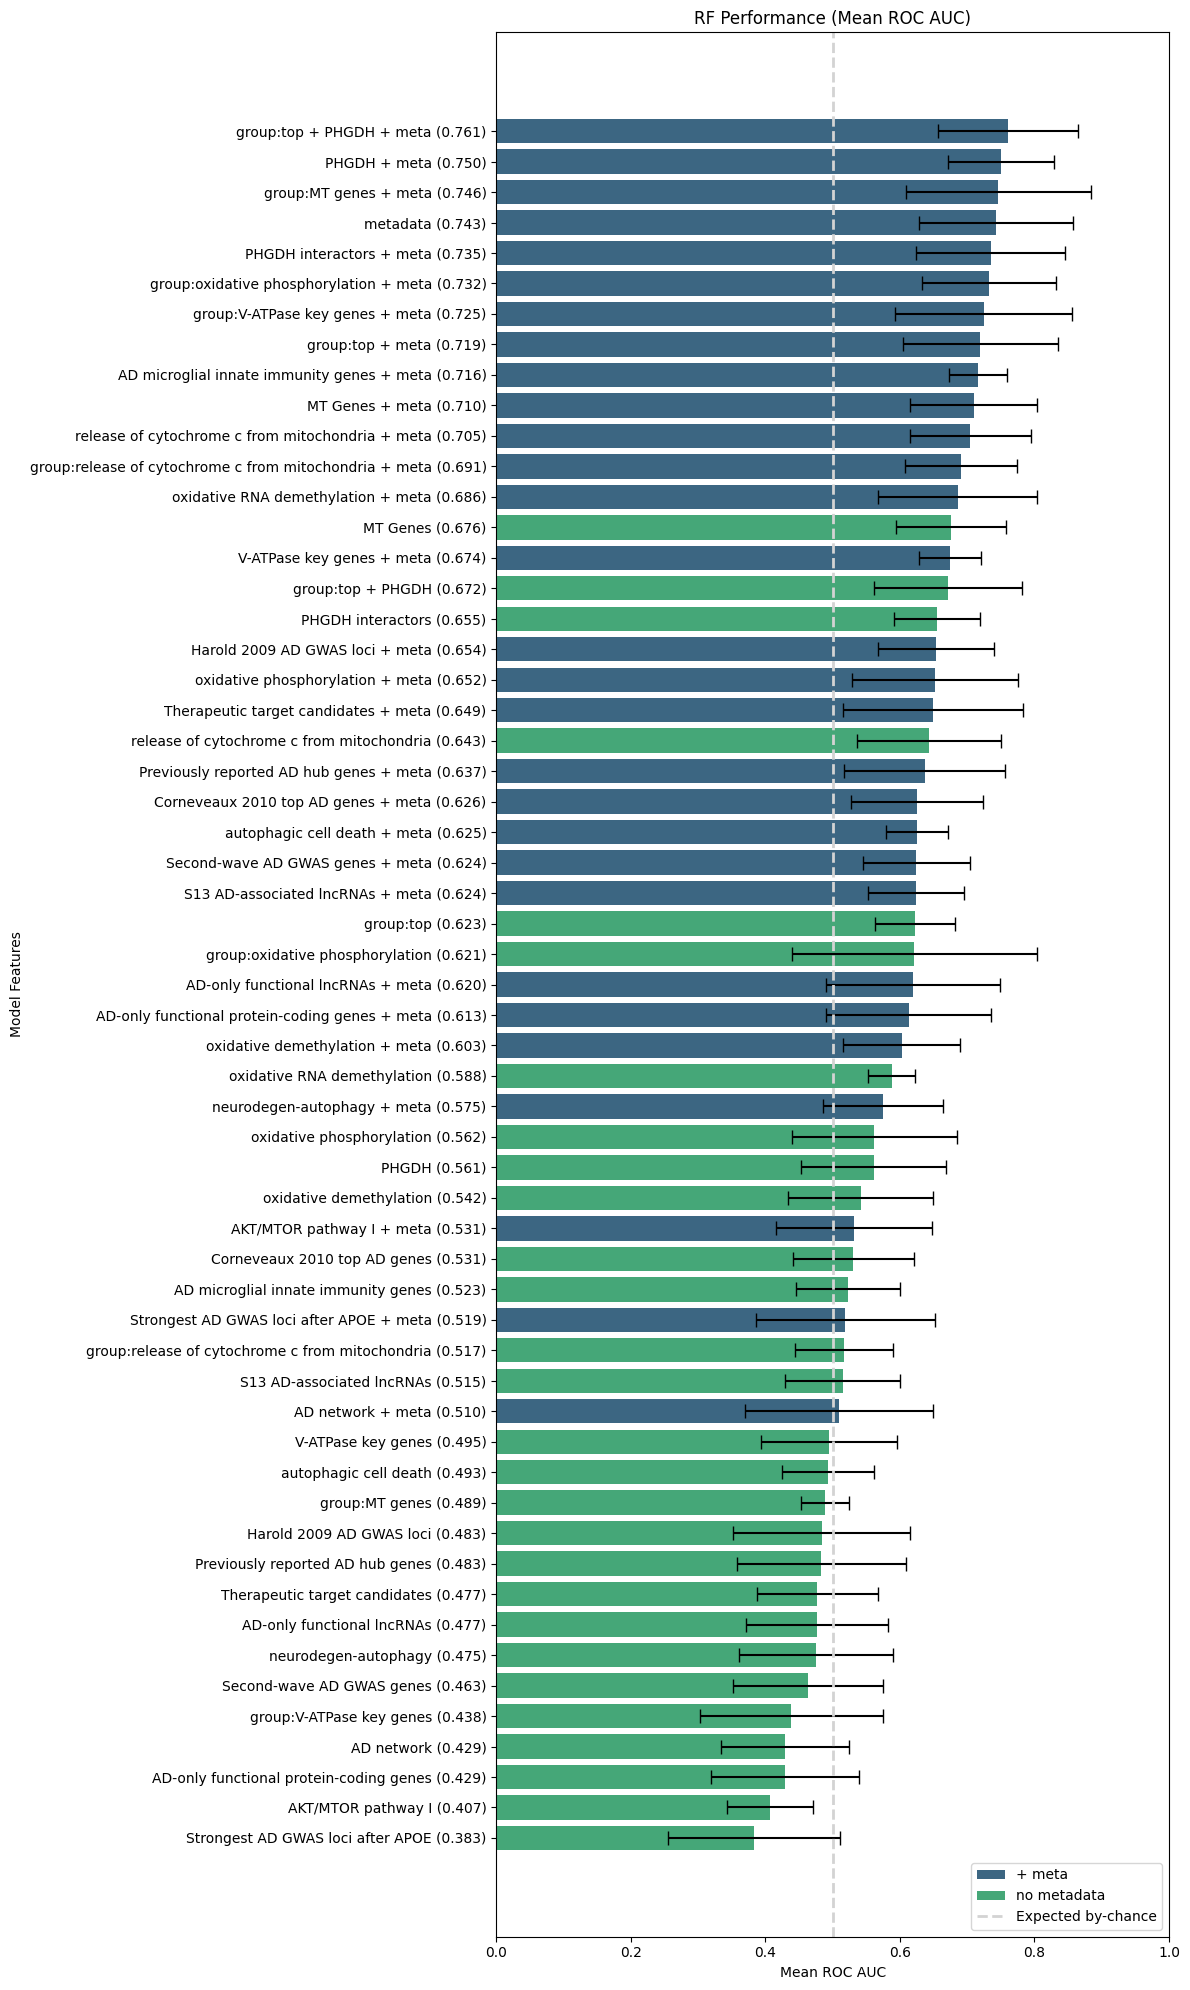

In [ ]:
# Prepare data for plotting
model_names = []
mean_roc_auc = []
std_roc_auc = []
model_type = []
feats=[]
has_meta=[]

for name, data in scores.items():
  if data['model']=='random forest':
    model_names.append(name)
    feats.append(data['features'] + f' ({data['score'].mean():.3f})')
    mean_roc_auc.append(data['score'].mean())
    std_roc_auc.append(data['score'].std())
    model_type.append(data['model'])
    has_meta.append("+ meta" if "meta" in data['features'] else "no metadata")

plot_df = pd.DataFrame({
    'Model': model_names,
    'features': feats,
    'Mean ROC AUC': mean_roc_auc,
    'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type,
    "Has metadata": has_meta
})

#sort
plot_df = plot_df.sort_values(by='Mean ROC AUC', ascending=False)

# Create the plot
plt.figure(figsize=(12,20))
sns.barplot(x='Mean ROC AUC', y='features', data=plot_df, hue='Has metadata', dodge=False, palette='viridis')

# Add error bars
plt.errorbar(x=plot_df['Mean ROC AUC'], y=plot_df['features'],
             xerr=plot_df['Std Dev ROC AUC'], fmt='none', capsize=5, color='black')

# Add a vertical dotted line at x=0.5 for 'by-chance' AUC
plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('RF Performance (Mean ROC AUC)')
plt.xlabel('Mean ROC AUC')
plt.ylabel('Model Features')
#y axis ticks labels according to features list
#plt.yticks(range(len(model_names)), feats)
plt.xlim(0, 1) 
plt.legend(loc='lower right') 
plt.tight_layout()
plt.show()

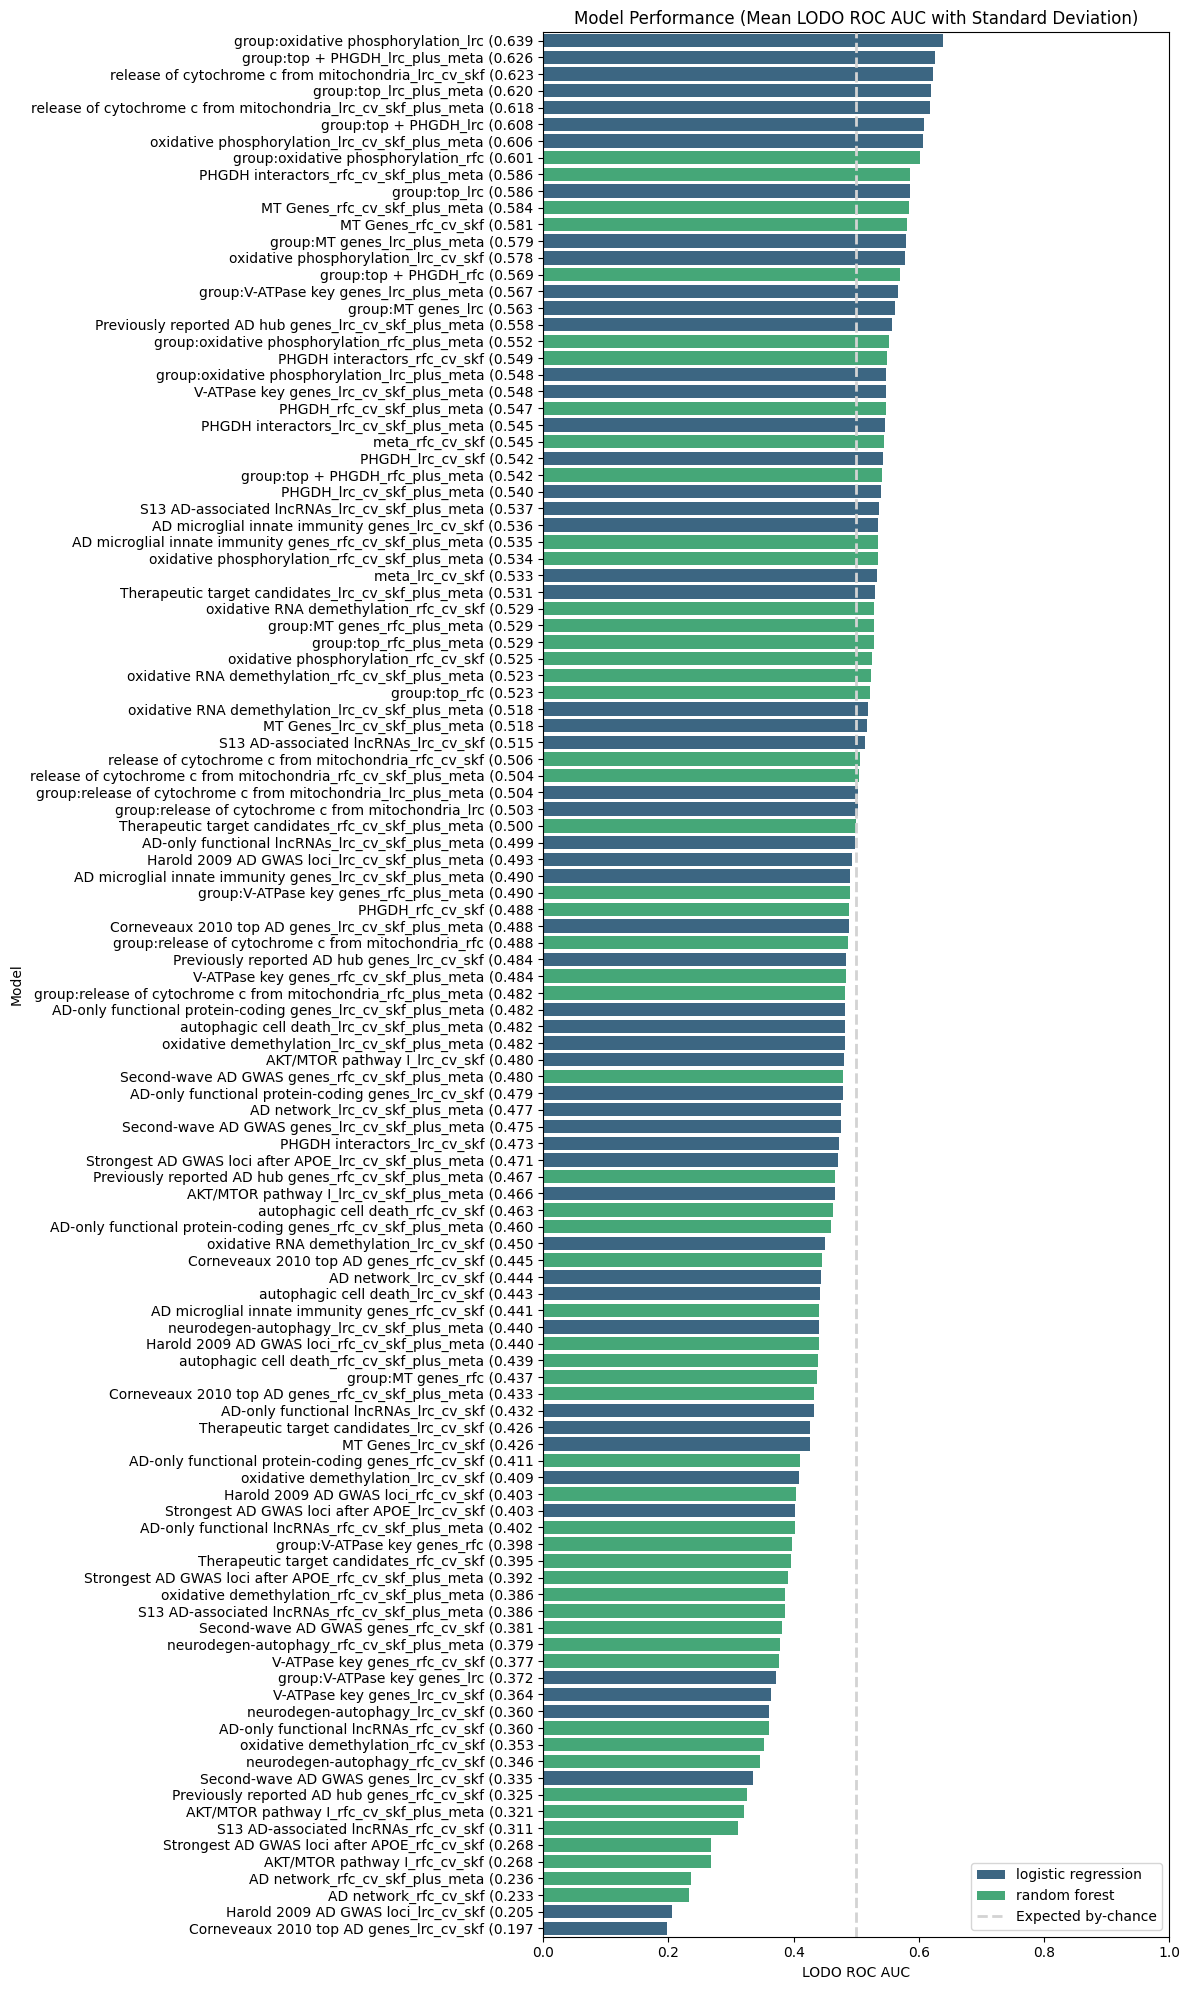

In [ ]:
#prep data
model_names = []
mean_roc_auc = []
#std_roc_auc = []
model_type = []
feats=[]

for name, data in scores.items():
    model_names.append(name + f' ({data['lodo_roc_auc'].mean():.3f}')
    feats.append(data['features'])
    mean_roc_auc.append(data['lodo_roc_auc'].mean())
    #std_roc_auc.append(data['lodo_roc_auc'].std())
    model_type.append(data['model'])

plot_df = pd.DataFrame({
    'Model': model_names,
    'LODO ROC AUC': mean_roc_auc,
    #'Std Dev ROC AUC': std_roc_auc,
    'Classifier': model_type
})

#sort
plot_df = plot_df.sort_values(by='LODO ROC AUC', ascending=False)

#plot
plt.figure(figsize=(12,20))
sns.barplot(x='LODO ROC AUC', y='Model', data=plot_df, hue='Classifier', dodge=False, palette='viridis')

#by chance
plt.axvline(x=0.5, color='lightgrey', linestyle='--', linewidth=2, label='Expected by-chance')

plt.title('Model Performance (Mean LODO ROC AUC with Standard Deviation)')
plt.xlabel('LODO ROC AUC')
plt.ylabel('Model')
#y axis ticks labels according to features list
# plt.yticks(range(len(model_names)), feats)
plt.xlim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [22]:
silver_seq_meta.head()

,donor_id,donor_id_alias,sample_id_alias,year_sample,donor_status_score,donor_group,braak_stage,apoe,apoe_carrier,apoe_dose,age_at_death,sex,max_year,age_at_collection,is_last_sample,apoe2
0,8140,AD_1,AD_1_02_1,2002,A,AD,5,34,apoe4,apoe4,85,F,2013,74,False,1
1,8140,AD_1,AD_1_04_1,2004,A,AD,5,34,apoe4,apoe4,85,F,2013,76,False,1
2,8140,AD_1,AD_1_08_1,2008,A,AD,5,34,apoe4,apoe4,85,F,2013,80,False,1
3,8140,AD_1,AD_1_09_1,2009,A,AD,5,34,apoe4,apoe4,85,F,2013,81,False,1
4,8140,AD_1,AD_1_11_1,2011,A,AD,5,34,apoe4,apoe4,85,F,2013,83,False,1


In [25]:
scores['meta_lrc_cv_skf']

{'score': array([0.625     , 0.69583333, 0.68333333, 0.49166667, 0.89285714]),
 'lodo_roc_auc': np.float64(0.5329597890573501),
 'description': 'Metadata only, logistic regression, StratifiedKFold',
 'model': 'logistic regression',
 'features': 'metadata',
 'n_features': 3,
 'n_samples': 115}

In [26]:
scores['meta_rfc_cv_skf']

{'score': array([0.70833333, 0.8375    , 0.82083333, 0.53333333, 0.81349206]),
 'lodo_roc_auc': np.float64(0.5451549110085695),
 'description': 'Metadata only, random forest, StratifiedKFold',
 'model': 'random forest',
 'features': 'metadata',
 'n_features': 3,
 'n_samples': 115}

In [27]:
print(f'Random Forest Mean ROC AUC: {sum(scores['meta_rfc_cv_skf']['score'])/5}')
print(f'Logitic Regression Mean ROC AUC: {sum(scores['meta_lrc_cv_skf']['score'])/5}')

Random Forest Mean ROC AUC: 0.7426984126984127
Logitic Regression Mean ROC AUC: 0.6777380952380951


## How many MT genes are within the most variable ones?

In [ ]:
X.head()

In [28]:
# take top.1% most variable genes from X
top_perc=.5
gene_variances = X.var(axis=1).sort_values(ascending=False)

# Determine number of genes to keep
n_genes = int(len(gene_variances) * (top_perc / 100))
# Handle edge case where top_perc might result in 0 genes
#n_genes = max(1, n_genes)

top_genes = gene_variances.head(n_genes).index

X_filtered = X.loc[top_genes]

X_filtered.shape


(53, 115)

In [29]:

from experiments.silver_seq import silver_seq_utils as utils

In [30]:
gene_names_top=utils.translate_ensemble(top_genes)
gene_names_top.head()

,symbol
37,MTND2P28
39,MTCO1P12
43,MTATP6P1
44,MTCO3P12
1242,MACF1


In [31]:
gene_names_top_mt = [g for g in gene_names_top if 'MT' in str(g)]
len(gene_names_top_mt)/len(gene_names_top)

0.5094339622641509

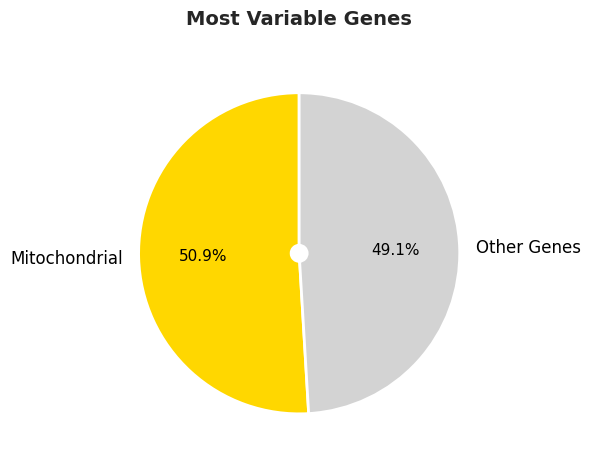

In [ ]:
mitochondrial_count = len(gene_names_top_mt)
other_genes_count = len(gene_names_top) - mitochondrial_count

counts = [mitochondrial_count, other_genes_count]
labels = ['Mitochondrial', 'Other Genes']
colors = ['#FFD700', '#D3D3D3']  

fig, ax = plt.subplots(figsize=(6, 6))
#pie chart
wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',      
    startangle=90,          
    colors=colors,
    textprops=dict(color="black", fontsize=12),
    wedgeprops=dict(width=0.95, edgecolor='white', linewidth=2) # "width" turns it into a modern donut chart
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('normal')

plt.title("Most Variable Genes", fontsize=14, pad=20, weight="bold")
plt.tight_layout()
plt.show()

## Better summary plots

In [ ]:
#parse to dataframe for easier plotting
data_list = []

for key, info in scores.items():
    #info to keep
    feat_str = info['features']
    model_raw = info['model']
    lodo_auc = info['lodo_roc_auc']

    #mean for 5-fold
    mean_5fold_auc = np.mean(info['score'])

    #for name outlier (already fixed above but doesn;t hurt)
    if 'logistic' in model_raw.lower():
        model_label = 'Logistic Regression'
    elif 'random' in model_raw.lower() or 'rf' in model_raw.lower():
        model_label = 'Random Forest'
    else:
        model_label = model_raw.title()

    #check for metadata and clean up the feature label string
    if '+ meta' in feat_str:
        base_features = feat_str.replace('+ meta', '').strip()
        metadata_label = 'With Metadata'
    elif '+meta' in feat_str:
        base_features = feat_str.replace('+meta', '').strip()
        metadata_label = 'With Metadata'
    elif feat_str=='metadata':
        base_features = 'Metadata-only'
        metadata_label = 'With Metadata'
    else:
        base_features = feat_str.strip()
        metadata_label = 'Without Metadata'

    #5-fold row
    data_list.append({
        'Feature Set': base_features,
        'Model': model_label,
        'Metadata': metadata_label,
        'Validation Scheme': '5-Fold CV (Mean)',
        'ROC AUC': mean_5fold_auc
    })

    #Lodo row
    data_list.append({
        'Feature Set': base_features,
        'Model': model_label,
        'Metadata': metadata_label,
        'Validation Scheme': 'LODO CV',
        'ROC AUC': lodo_auc
    })

#to pandas
df = pd.DataFrame(data_list)

In [113]:
df.head()

,Feature Set,Model,Metadata,Validation Scheme,ROC AUC
0,Metadata-only,Logistic Regression,With Metadata,5-Fold CV (Mean),0.677738
1,Metadata-only,Logistic Regression,With Metadata,LODO CV,0.532960
2,Metadata-only,Random Forest,With Metadata,5-Fold CV (Mean),0.742698
3,Metadata-only,Random Forest,With Metadata,LODO CV,0.545155
4,AD network,Logistic Regression,With Metadata,5-Fold CV (Mean),0.601032


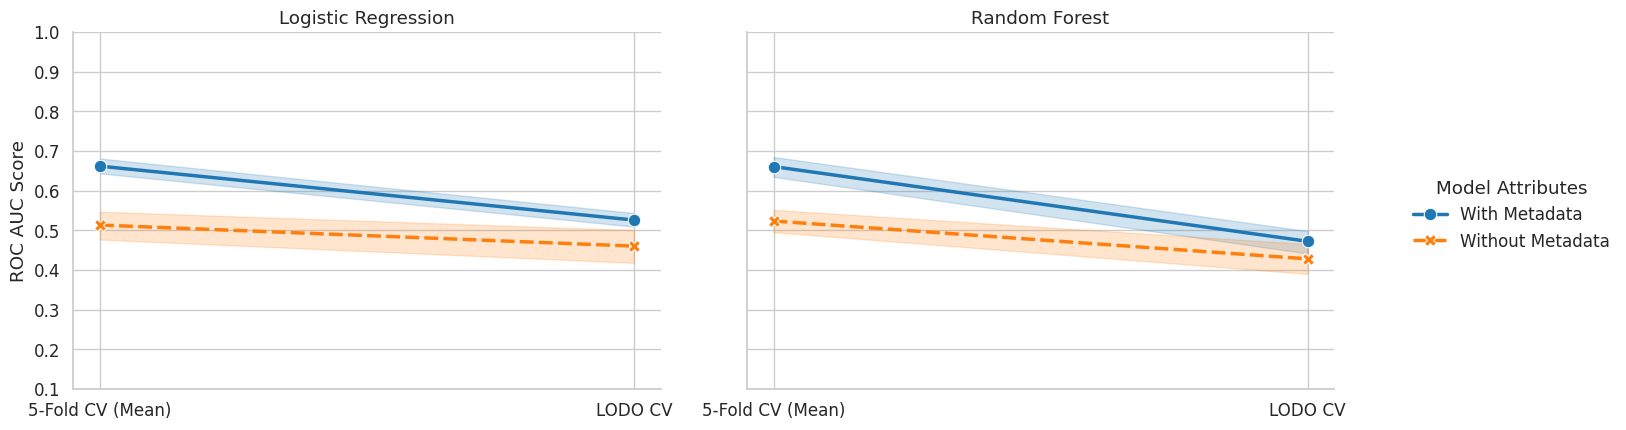

In [ ]:
g_compact = sns.FacetGrid(df, col="Model", height=4.5, aspect=1.3, sharey=True)
g_compact.map_dataframe(
    sns.lineplot,
    x="Validation Scheme",
    y="ROC AUC",
    hue="Metadata",
    style="Metadata",
    palette="tab10",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=9
)

g_compact.add_legend(title="Model Attributes", bbox_to_anchor=(1.02, 0.5), loc='center left')
g_compact.set_titles(col_template="{col_name}")
g_compact.set_axis_labels("", "ROC AUC Score")
g_compact.set(ylim=(0.1, 1.0))

plt.tight_layout()
plt.show()
#g_compact.savefig("/lhinojosa/classes/BENG203/project/test_plots/slope_graph_compact.png", dpi=300)

In [110]:
df.shape

(228, 5)

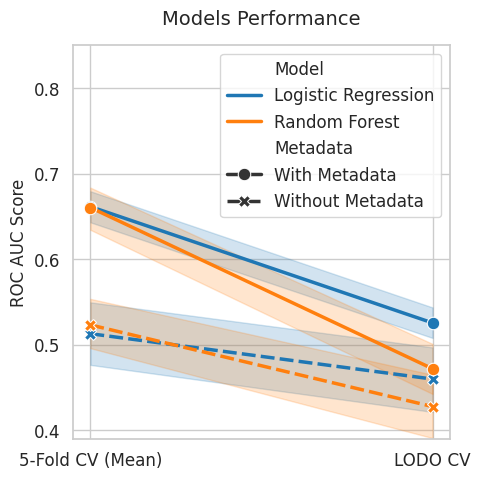

In [ ]:
#single plot
plt.figure(figsize=(5,5))

sns.lineplot(
    data=df,
    x="Validation Scheme",
    y="ROC AUC",
    hue="Model",        
    style="Metadata",         
    palette="tab10",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=9        
)

# Clean up layout and labels
plt.title("Models Performance", fontsize=14, pad=15)
plt.xlabel("")
plt.ylabel("ROC AUC Score", fontsize=12)
plt.ylim(0.39, 0.85)

plt.legend(title="", loc='best')

plt.tight_layout()
plt.show()

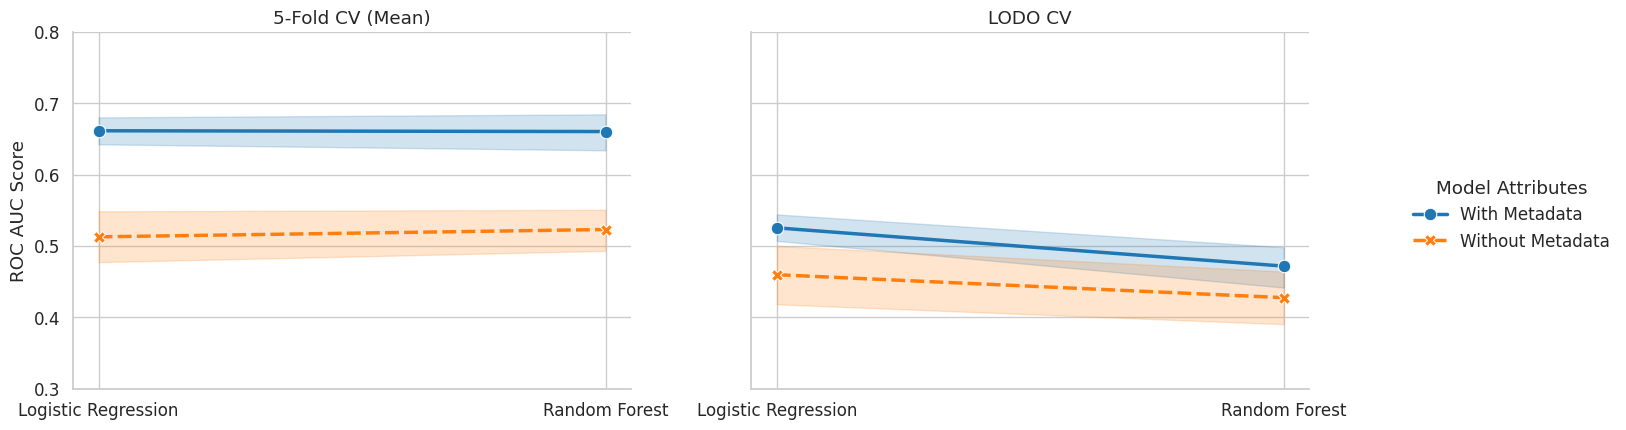

In [ ]:
g_compact = sns.FacetGrid(df, col="Validation Scheme", height=4.5, aspect=1.3, sharey=True)

#mep to model
g_compact.map_dataframe(
    sns.lineplot,
    x="Model",               
    y="ROC AUC",
    hue="Metadata",
    style="Metadata",
    palette="tab10",
    markers=True,
    dashes=True,
    linewidth=2.5,
    markersize=9##
)

#pwety
g_compact.add_legend(title="Model Attributes", bbox_to_anchor=(1.02, 0.5), loc='center left')
g_compact.set_titles(col_template="{col_name}")
g_compact.set_axis_labels("", "ROC AUC Score") # You can optionally remove "" if x-axis labels (LR, RF) are self-explanatory

#diplay window
g_compact.set(ylim=(0.3, 0.8))

plt.tight_layout()
plt.show()

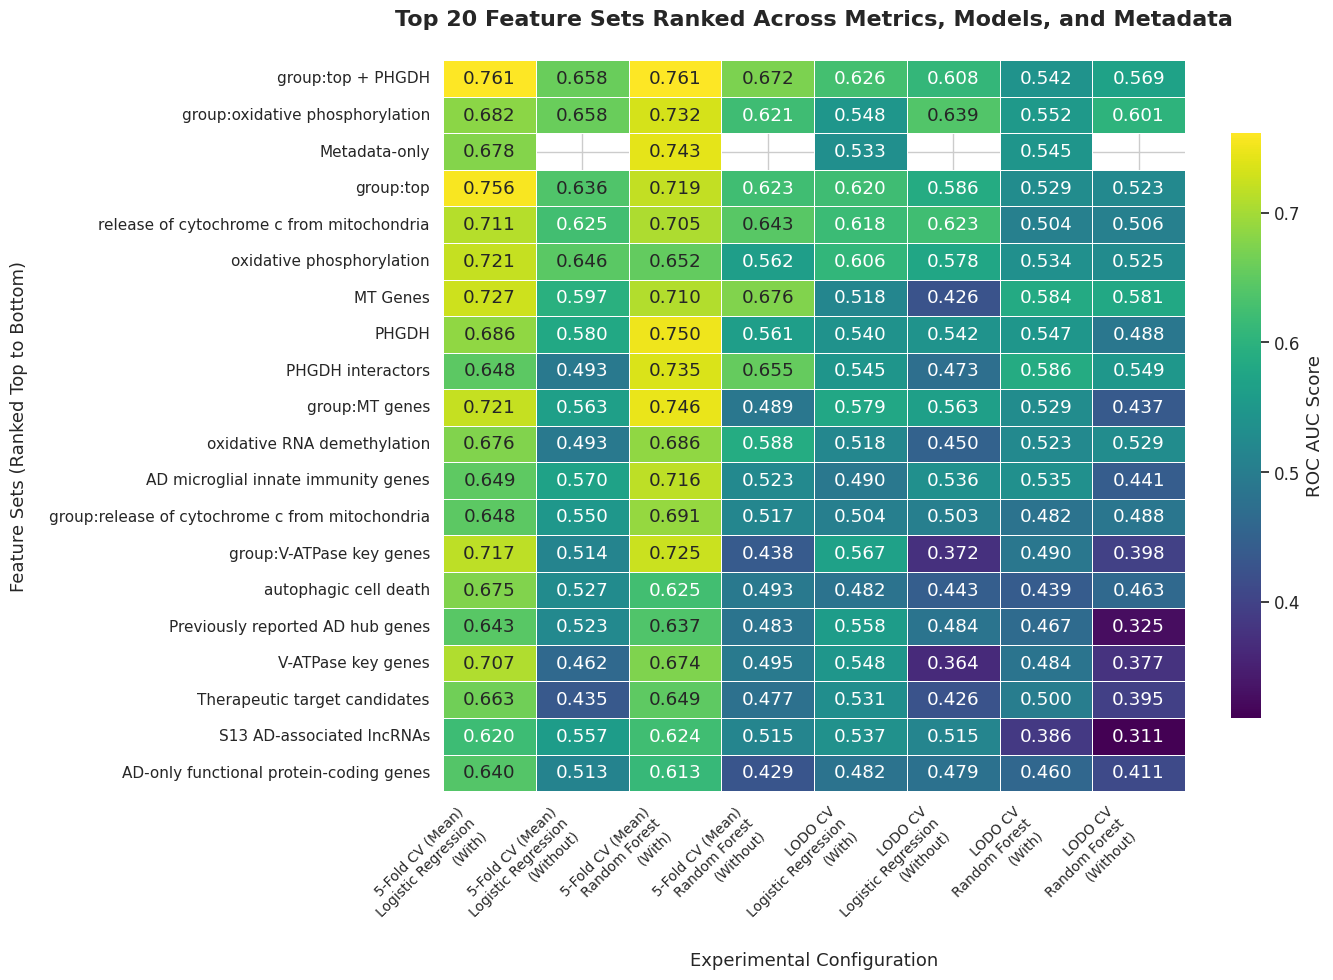

In [ ]:
# find da top

# Calculate the mean performance for each feature set across all conditions
mean_performances = df.groupby('Feature Set')['ROC AUC'].mean()

# Grab the names of the top 20 highest-performing feature sets
top_20_features = mean_performances.nlargest(20).index

# Filter to keep only these top 20 features
df_top20 = df[df['Feature Set'].isin(top_20_features)].copy()


#pivoooot

# Pivot the data so Feature Sets are rows, and our 8 conditions become columns
# (2 Validation Schemes x 2 Models x 2 Metadata options = 8 columns)
matrix_data = df_top20.pivot_table(
    index='Feature Set',
    columns=['Validation Scheme', 'Model', 'Metadata'],
    values='ROC AUC'
)

# Sort the rows hierarchically by overall performance
matrix_data = matrix_data.reindex(matrix_data.mean(axis=1).sort_values(ascending=False).index)


#labels

# The pivot creates a MultiIndex for columns. We can flatten it into readable strings:
clean_column_labels = [
    f"{scheme}\n{model}\n({meta.replace(' Metadata', '')})"
    for scheme, model, meta in matrix_data.columns
]

# Assign the flattened labels back to the matrix copy for plotting
plot_matrix = matrix_data.copy()
plot_matrix.columns = clean_column_labels


#heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    plot_matrix,
    cmap="viridis",         
    annot=True,             #display num
    fmt=".3f",             
    linewidths=.7,          
    cbar_kws={'label': 'ROC AUC Score', 'shrink': 0.8},
    square=False
)

# Style details
plt.title("Top 20 Feature Sets Ranked Across Metrics, Models, and Metadata", fontsize=16, pad=25, weight='bold')
plt.ylabel("Feature Sets (Ranked Top to Bottom)", fontsize=13, labelpad=15)
plt.xlabel("Experimental Configuration", fontsize=13, labelpad=15)

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()